### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [82]:
df = pd.read_csv('data/raw.csv')

#### Show Top 5 Records

In [83]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [84]:
df.shape

(1001, 8)

In [85]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [86]:
df.duplicated().sum()

1

In [87]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1001 non-null   object
 1   race_ethnicity               1001 non-null   object
 2   parental_level_of_education  1001 non-null   object
 3   lunch                        1001 non-null   object
 4   test_preparation_course      1001 non-null   object
 5   math_score                   1001 non-null   int64 
 6   reading_score                1001 non-null   int64 
 7   writing_score                1001 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.7+ KB


In [88]:
df.nunique().reset_index(name='counts')

,index,counts
0,gender,2
1,race_ethnicity,5
2,parental_level_of_education,6
3,lunch,2
4,test_preparation_course,2
5,math_score,81
6,reading_score,72
7,writing_score,77


In [89]:
df.describe()

,math_score,reading_score,writing_score
count,1001.00000,1001.000000,1001.000000
mean,66.09990,69.185814,68.071928
std,15.15942,14.602583,15.198645
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,58.000000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

In [90]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [91]:
print("Categories in 'gender' variable:",end="" ) ,print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:",end=""),print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:['female' 'male']
Categories in 'race_ethnicity' variable:['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [92]:
num1=df.select_dtypes(include=['int']).columns
num1
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']

In [93]:
col1=df.select_dtypes(exclude =['int']).columns
col1
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

In [94]:
print(f'We have {len(num1)} numerical features : {num1}')

We have 3 numerical features : Index(['math_score', 'reading_score', 'writing_score'], dtype='object')


In [95]:
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [96]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [97]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [98]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [99]:
reading_full1 = df[df['reading_score'] == 100].count()
reading_full1

gender                         17
race_ethnicity                 17
parental_level_of_education    17
lunch                          17
test_preparation_course        17
math_score                     17
reading_score                  17
writing_score                  17
total score                    17
average                        17
dtype: int64

In [100]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

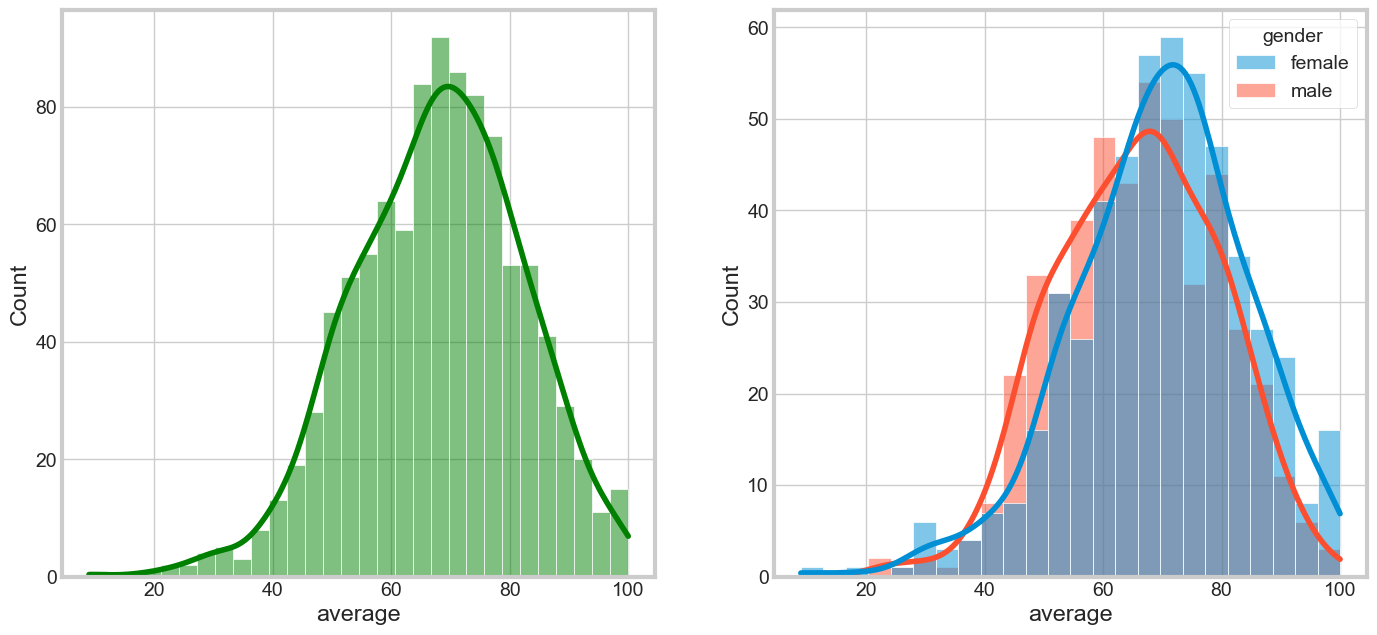

In [101]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x=df.average,bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x=df['average'],kde=True,hue='gender')
plt.show()

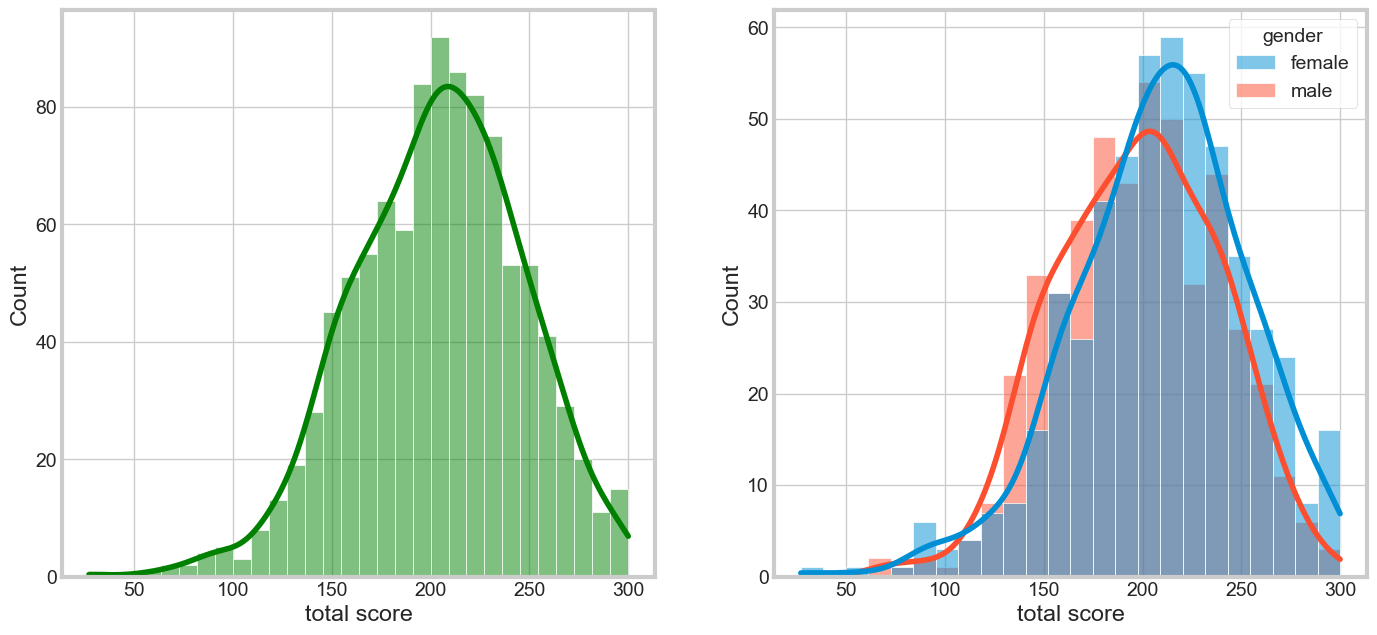

In [102]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

#####  Insights
- Female students tend to perform well then male students.

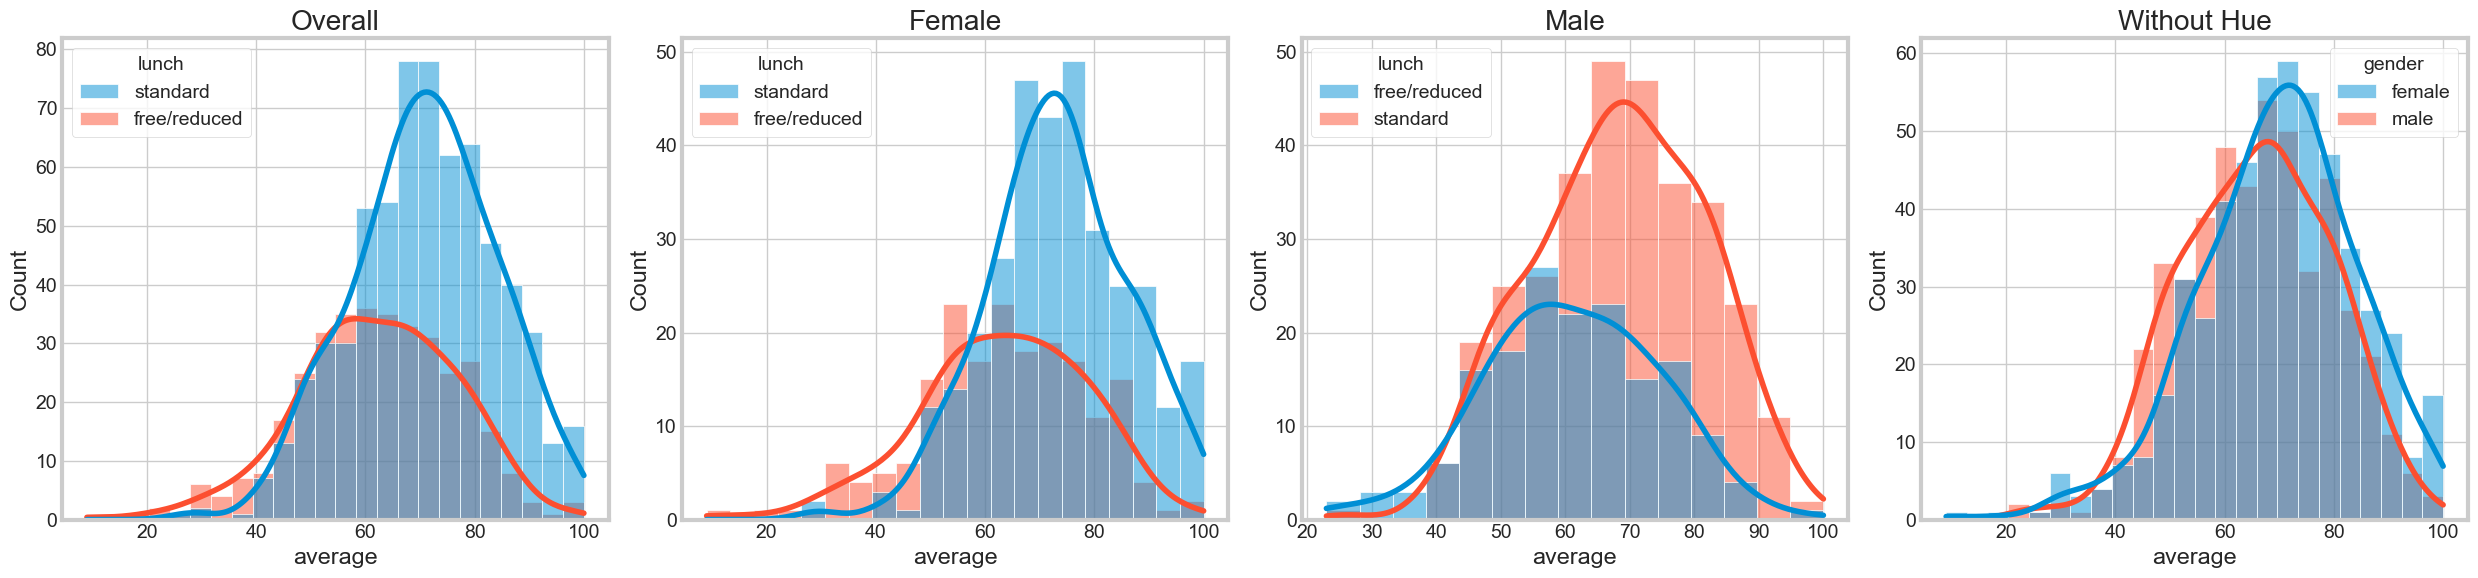

In [103]:
plt.figure(figsize=(25,6))

plt.subplot(1,4,1)
sns.histplot(data=df, x='average', kde=True, hue='lunch')
plt.title("Overall")

plt.subplot(1,4,2)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='lunch')
plt.title("Female")

plt.subplot(1,4,3)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='lunch')
plt.title("Male")

plt.subplot(1,4,4)
sns.histplot(data=df, x='average',hue='gender', kde=True)
plt.title("Without Hue")

plt.tight_layout()
plt.show()

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

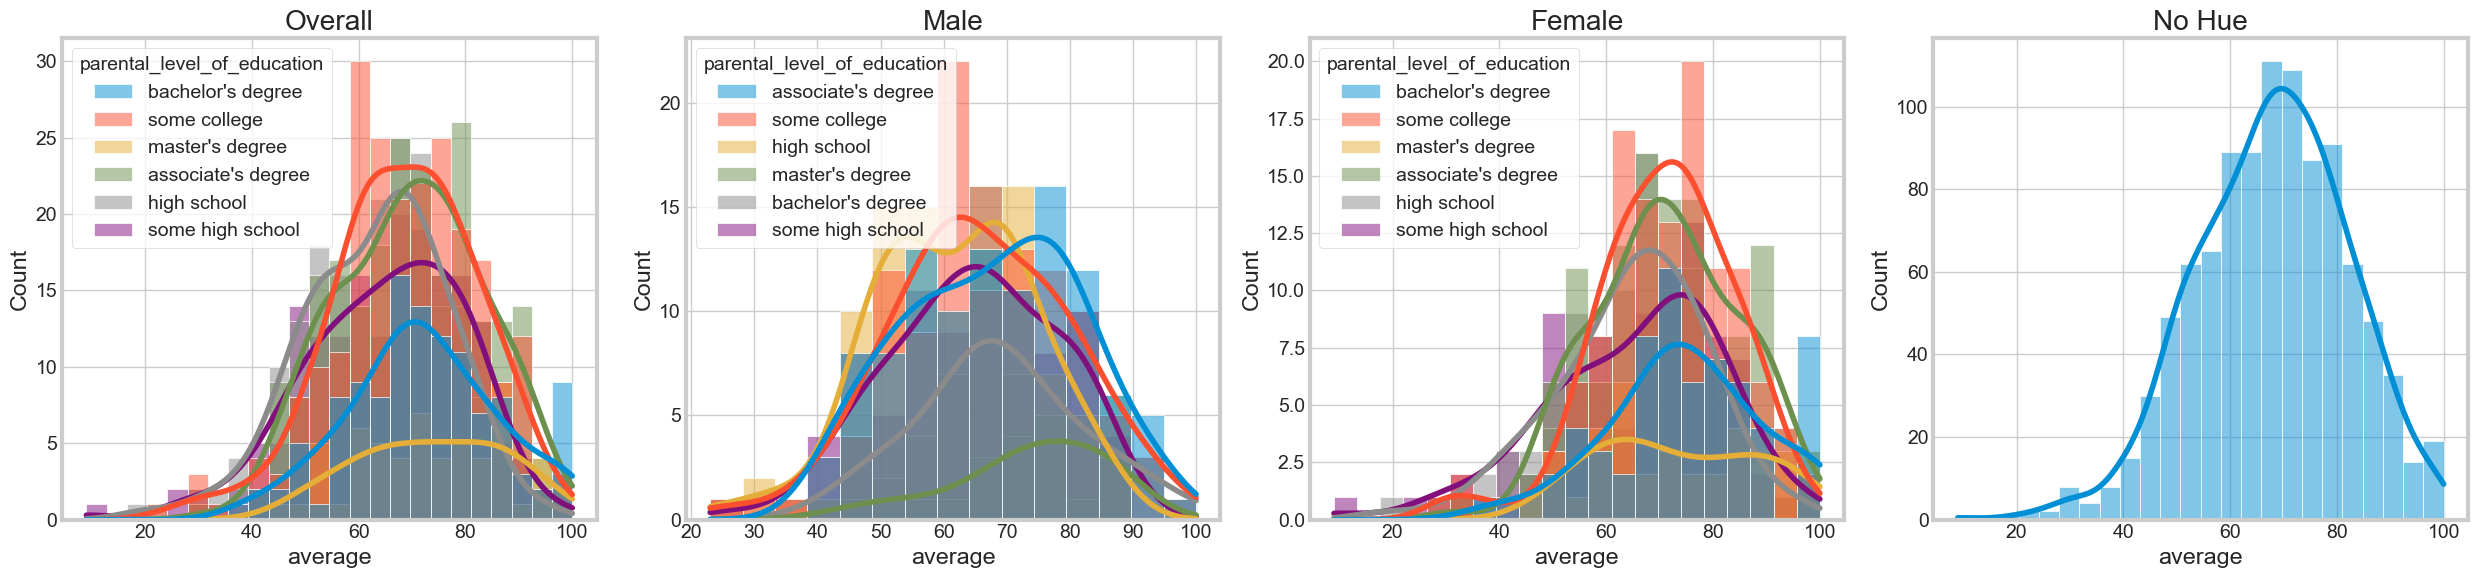

In [104]:
plt.figure(figsize=(25,6))

plt.subplot(1,4,1)
sns.histplot(data=df, x='average', kde=True, hue='parental_level_of_education')
plt.title("Overall")

plt.subplot(1,4,2)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='parental_level_of_education')
plt.title("Male")

plt.subplot(1,4,3)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='parental_level_of_education')
plt.title("Female")

plt.subplot(1,4,4)
sns.histplot(data=df, x='average', kde=True)
plt.title("No Hue")

plt.tight_layout()
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

In [105]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total score', 'average'],
      dtype='object')

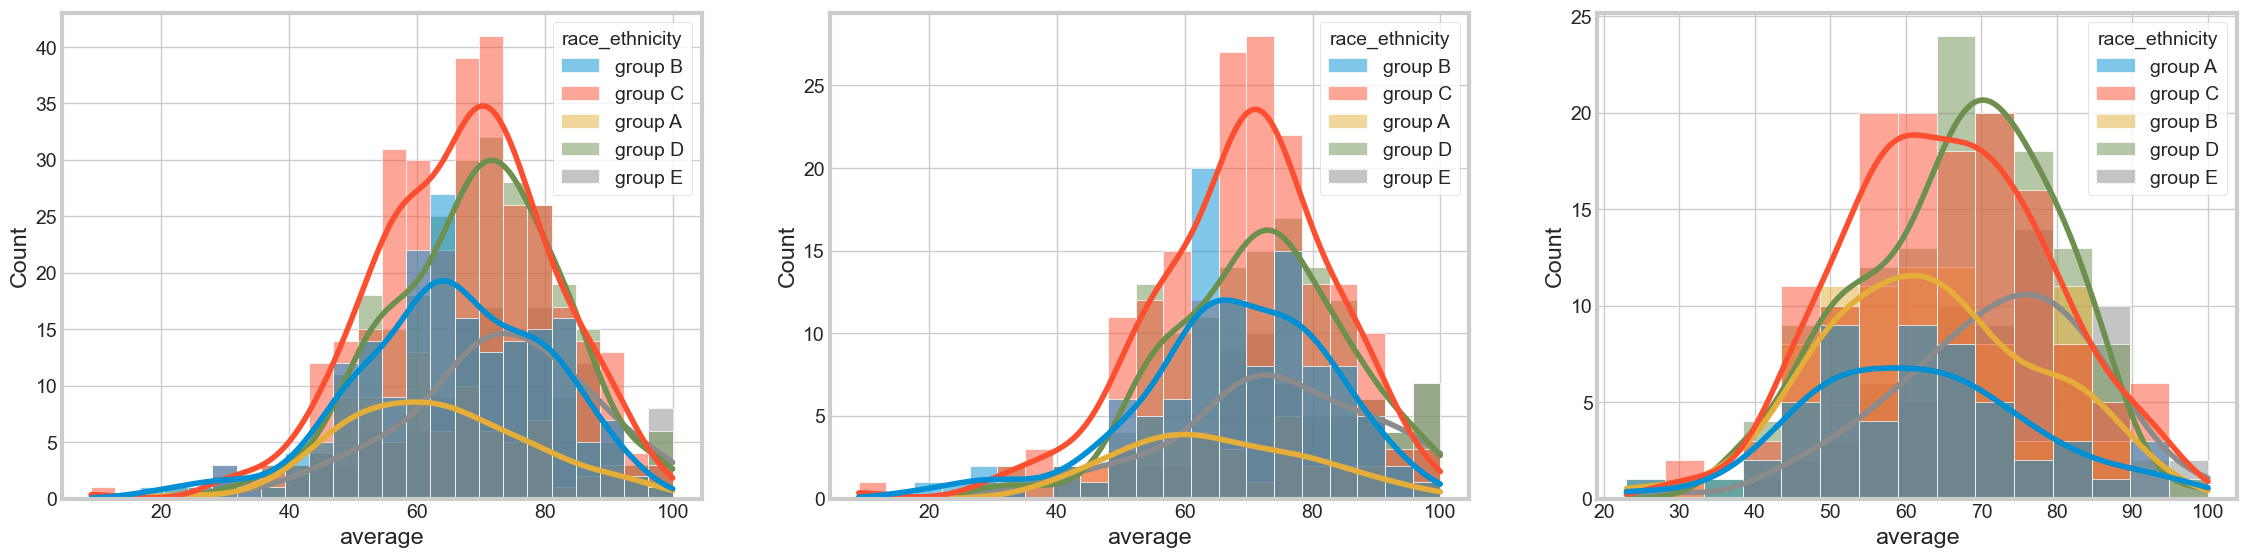

In [121]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax =sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(132)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(133)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

#### 4.2 Maximumum score of students in all three subjects

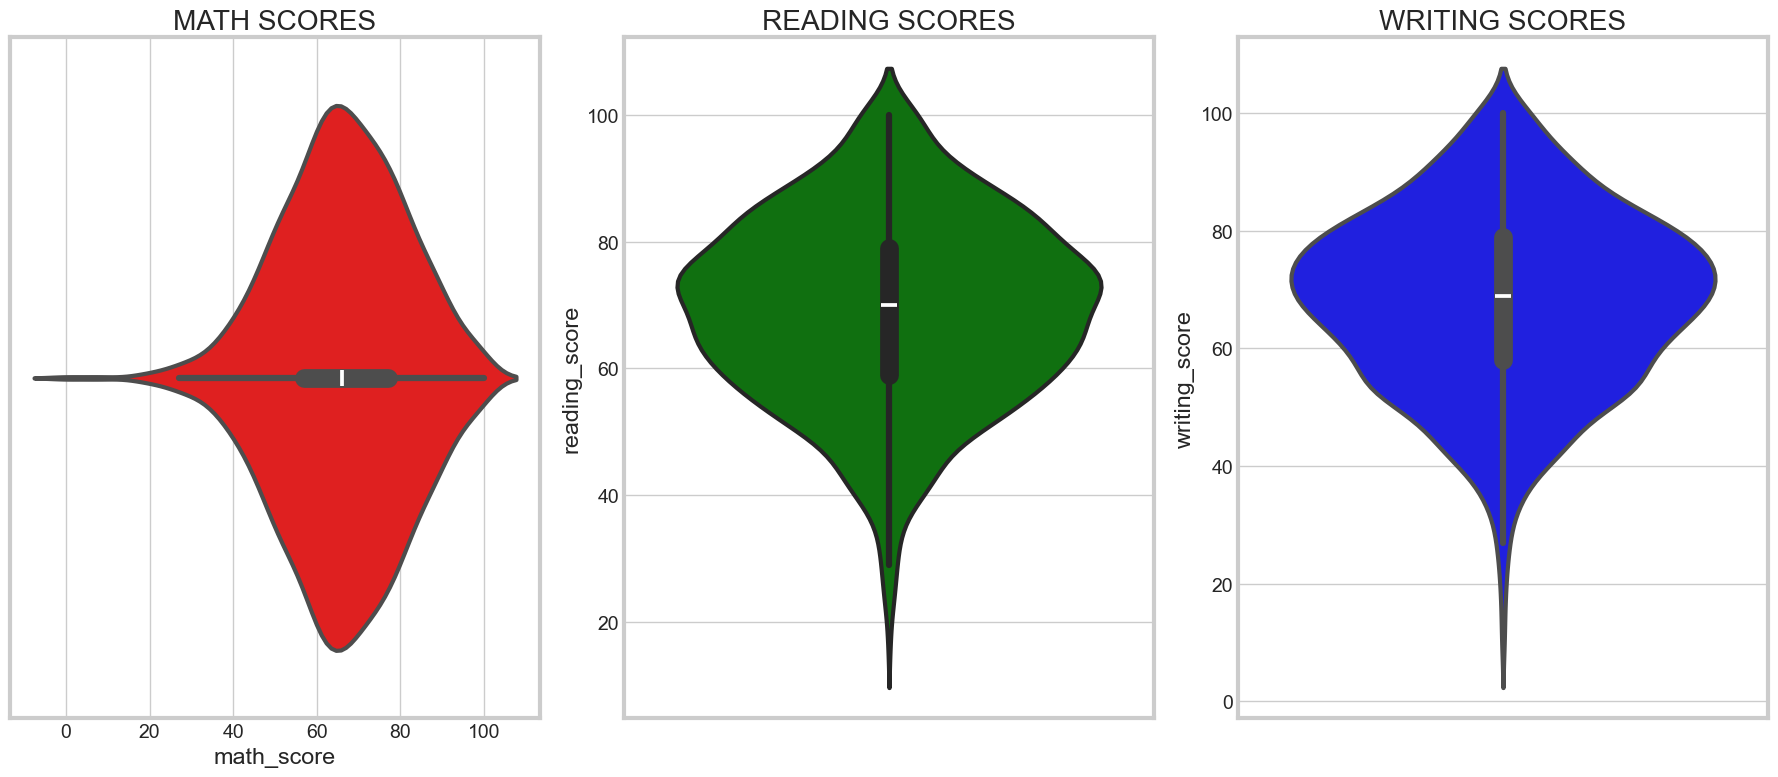

In [122]:
plt.figure(figsize=(18,8))

plt.subplot(1, 3, 1)
plt.title('MATH SCORES')
sns.violinplot(x='math_score', data=df, color='red', linewidth=3)

plt.subplot(1, 3, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3)

plt.subplot(1, 3, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=3)

plt.tight_layout()
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

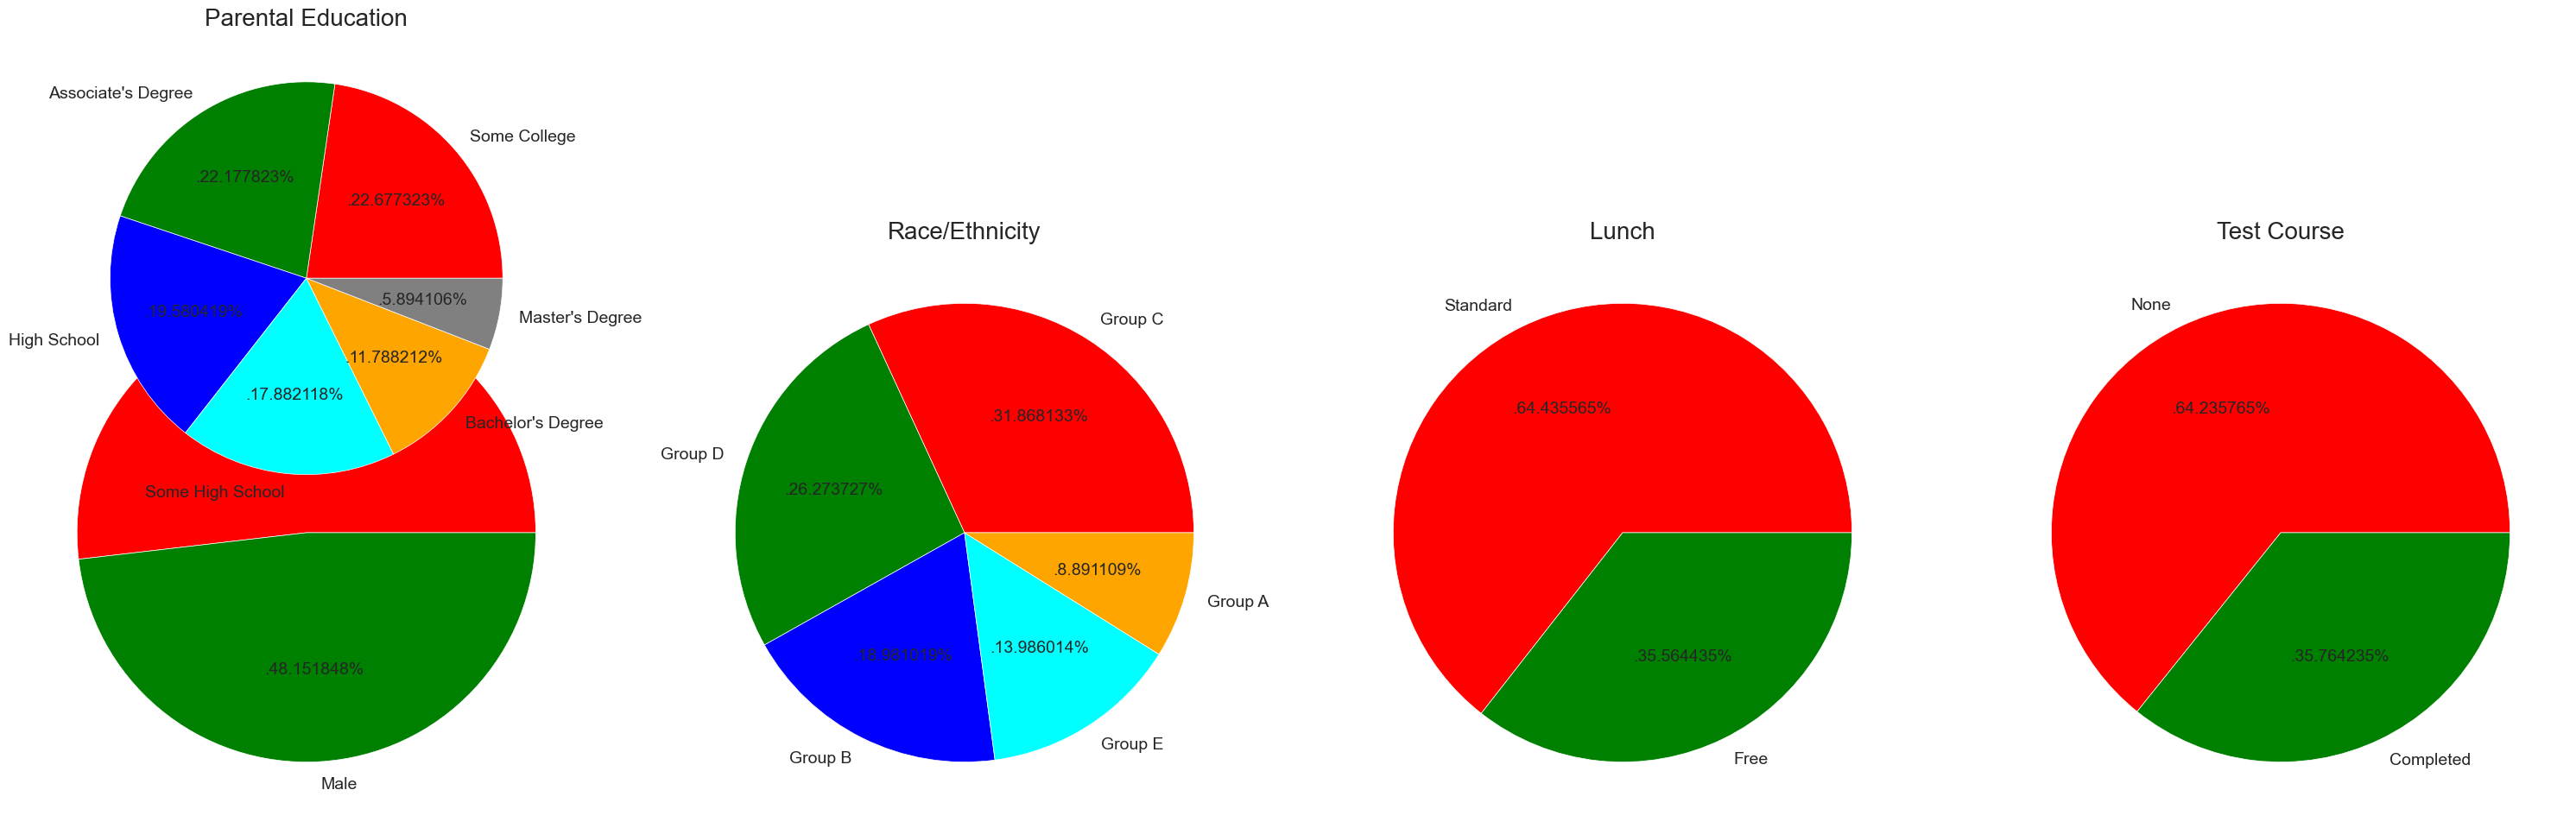

In [127]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 4, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 4, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 4, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 4, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(2, 4, 1)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

In [124]:
df.gender.value_counts()

gender
female    519
male      482
Name: count, dtype: int64

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

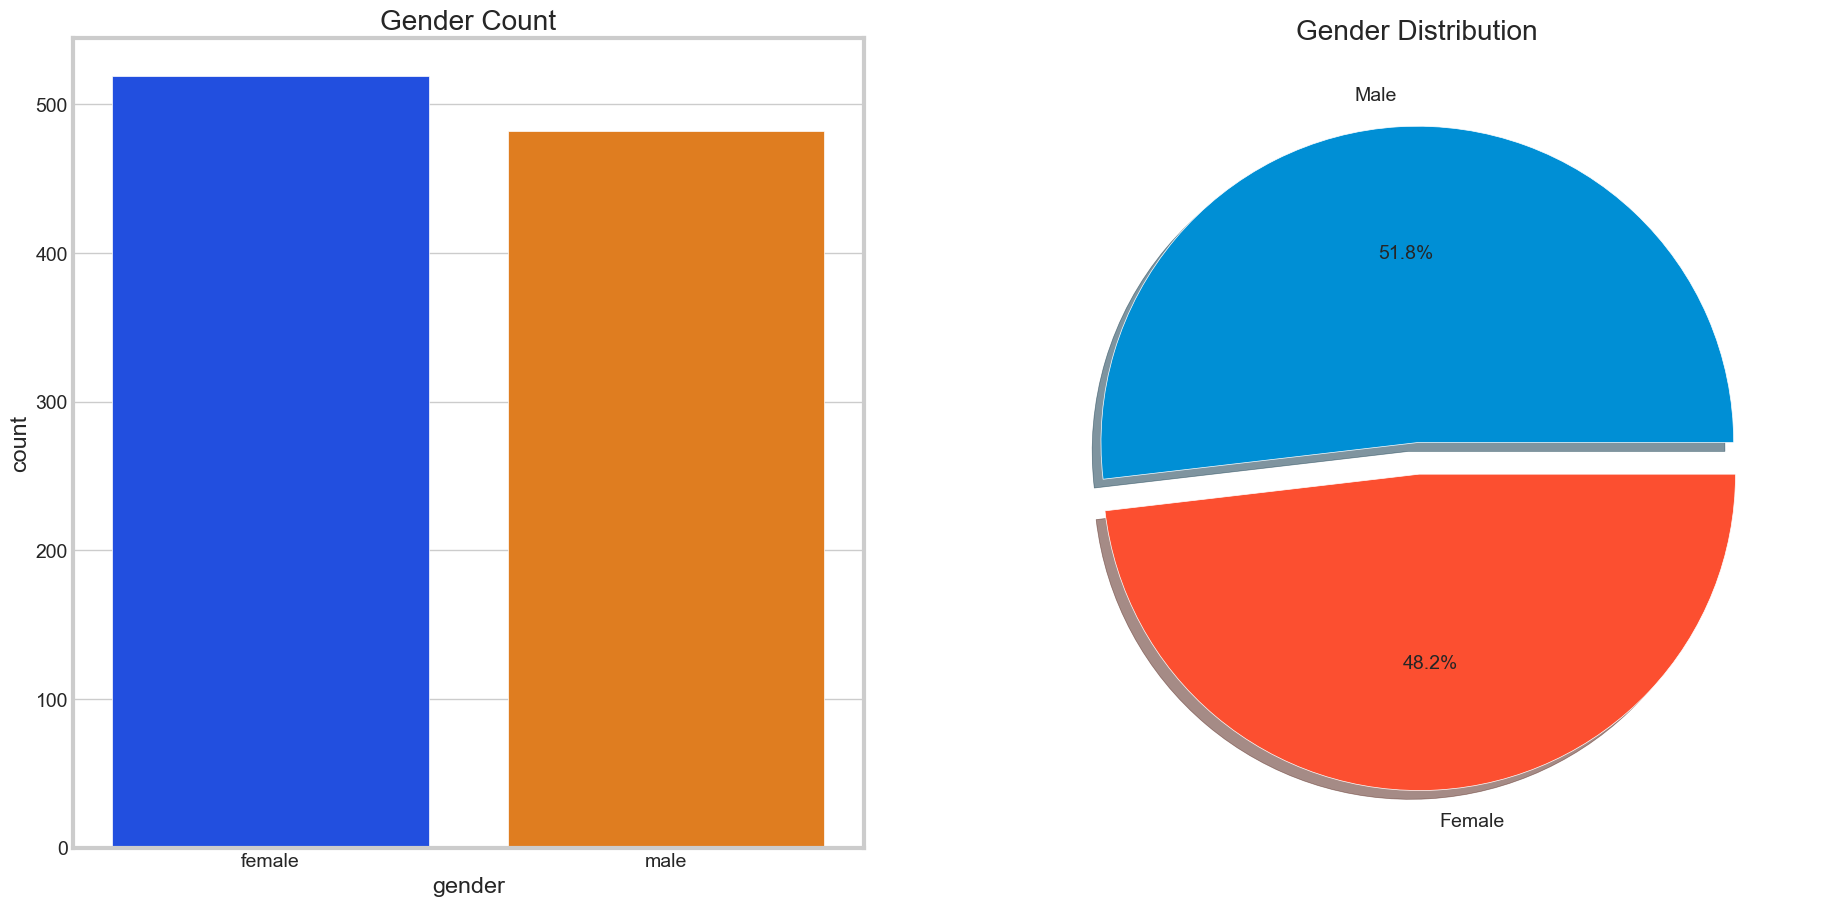

In [128]:
plt.figure(figsize=(20, 10))

# 1st plot: Countplot
plt.subplot(1, 2, 1)
sns.countplot(x='gender', data=df, palette='bright')
plt.title('Gender Count')

# 2nd plot: Pie chart
plt.subplot(1, 2, 2)
plt.pie(
    df['gender'].value_counts(),
    labels=['Male', 'Female'],
    explode=[0, 0.1],
    autopct='%1.1f%%',
    shadow=True
)
plt.title('Gender Distribution')

plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [110]:
gender_group = df.groupby('gender').mean(numeric_only=True)

In [129]:
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.658960,72.633911,72.493256,208.786127,69.595376
male,68.728216,65.473029,63.311203,197.512448,65.837483


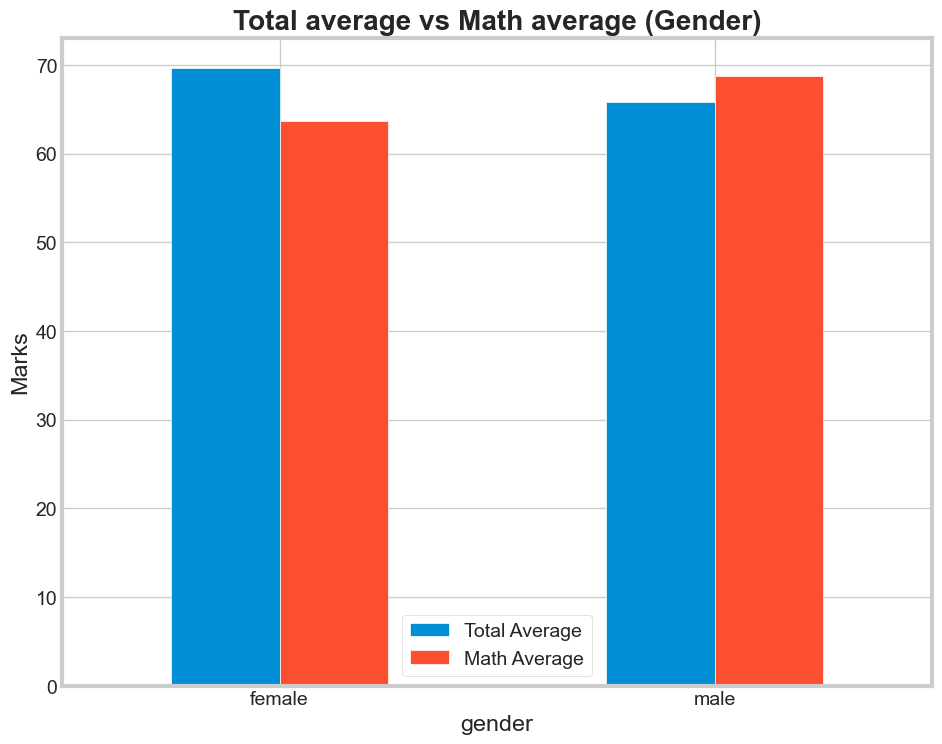

In [ ]:
gender_group[['average', 'math_score']].plot(kind='bar', figsize=(10, 8))
# pandas plotting
plt.ylabel("Marks")
plt.title("Total average vs Math average (Gender)", fontweight='bold')
plt.xticks(rotation=0)
plt.legend(['Total Average', 'Math Average'])

plt.show()

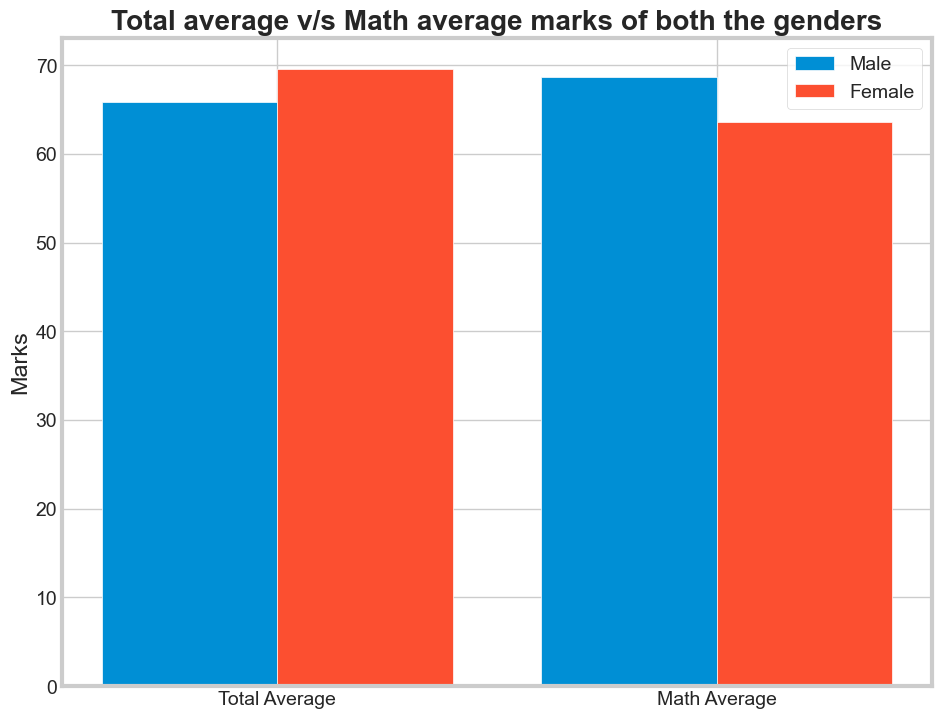

In [111]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

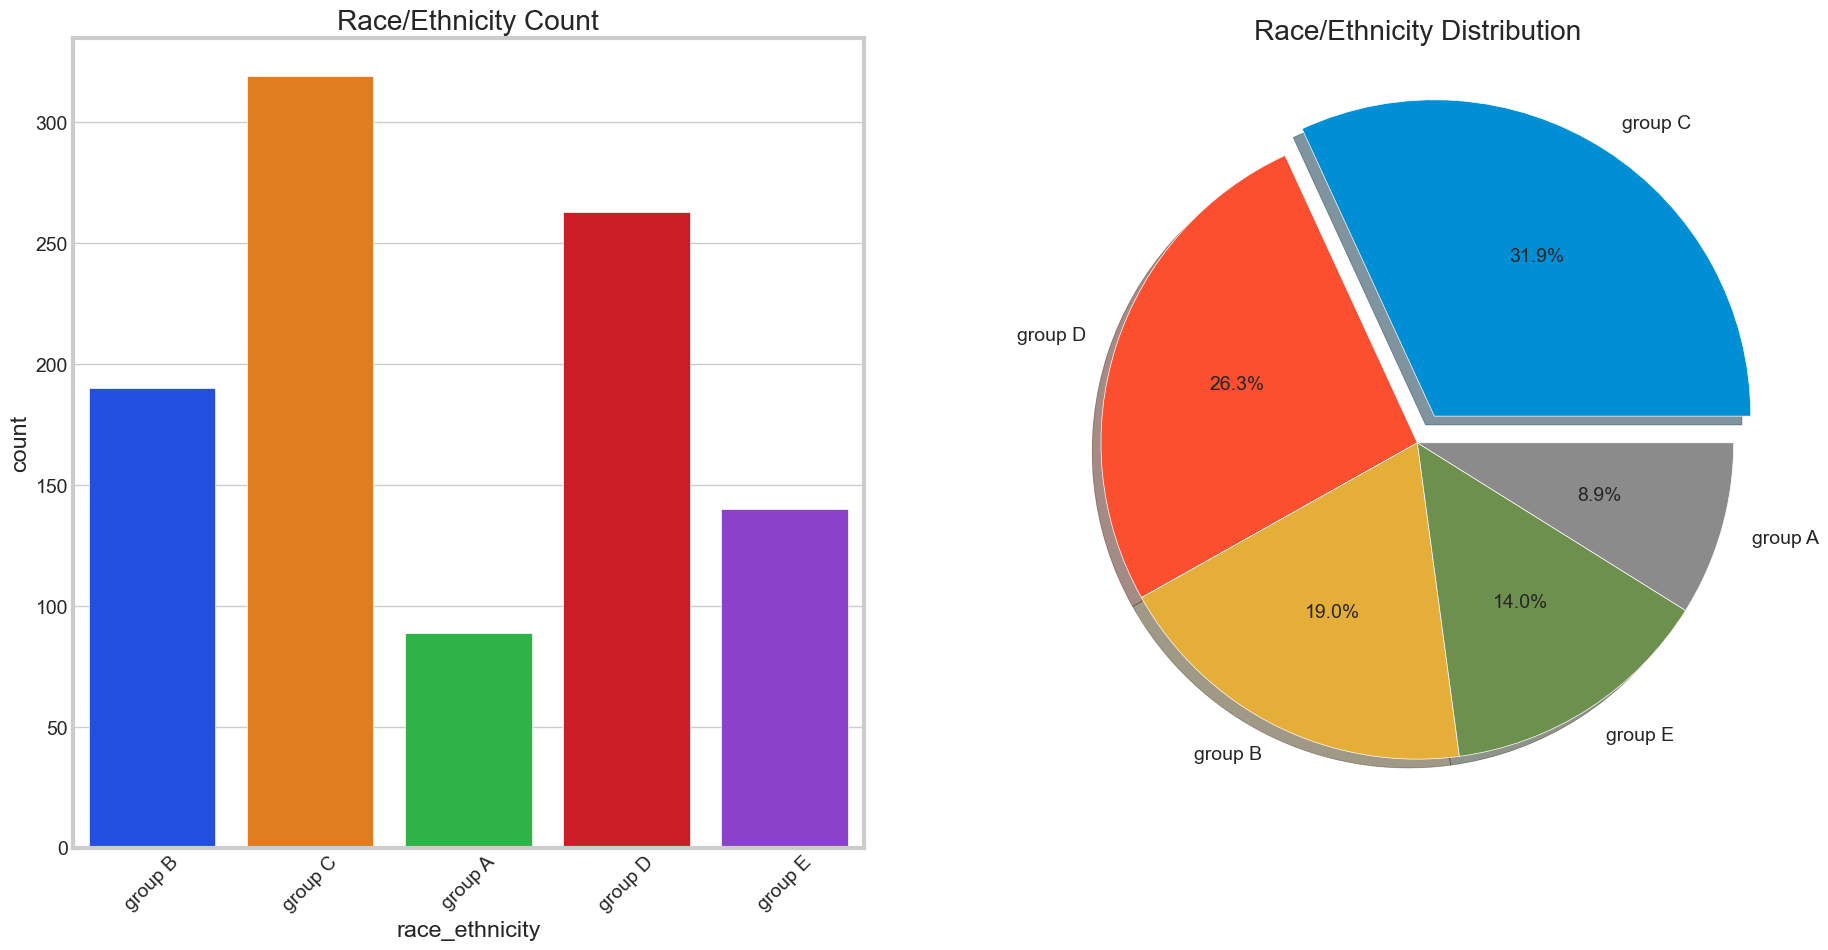

In [131]:
plt.figure(figsize=(20, 10))

# 1st plot: Countplot
plt.subplot(1, 2, 1)
sns.countplot(x='race_ethnicity', data=df, palette='bright')
plt.title('Race/Ethnicity Count')
plt.xticks(rotation=45)

# 2nd plot: Pie chart
plt.subplot(1, 2, 2)
counts = df['race_ethnicity'].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    explode=[0.1] + [0]*(len(counts)-1),
    autopct='%1.1f%%',
    shadow=True
)
plt.title('Race/Ethnicity Distribution')

plt.show()

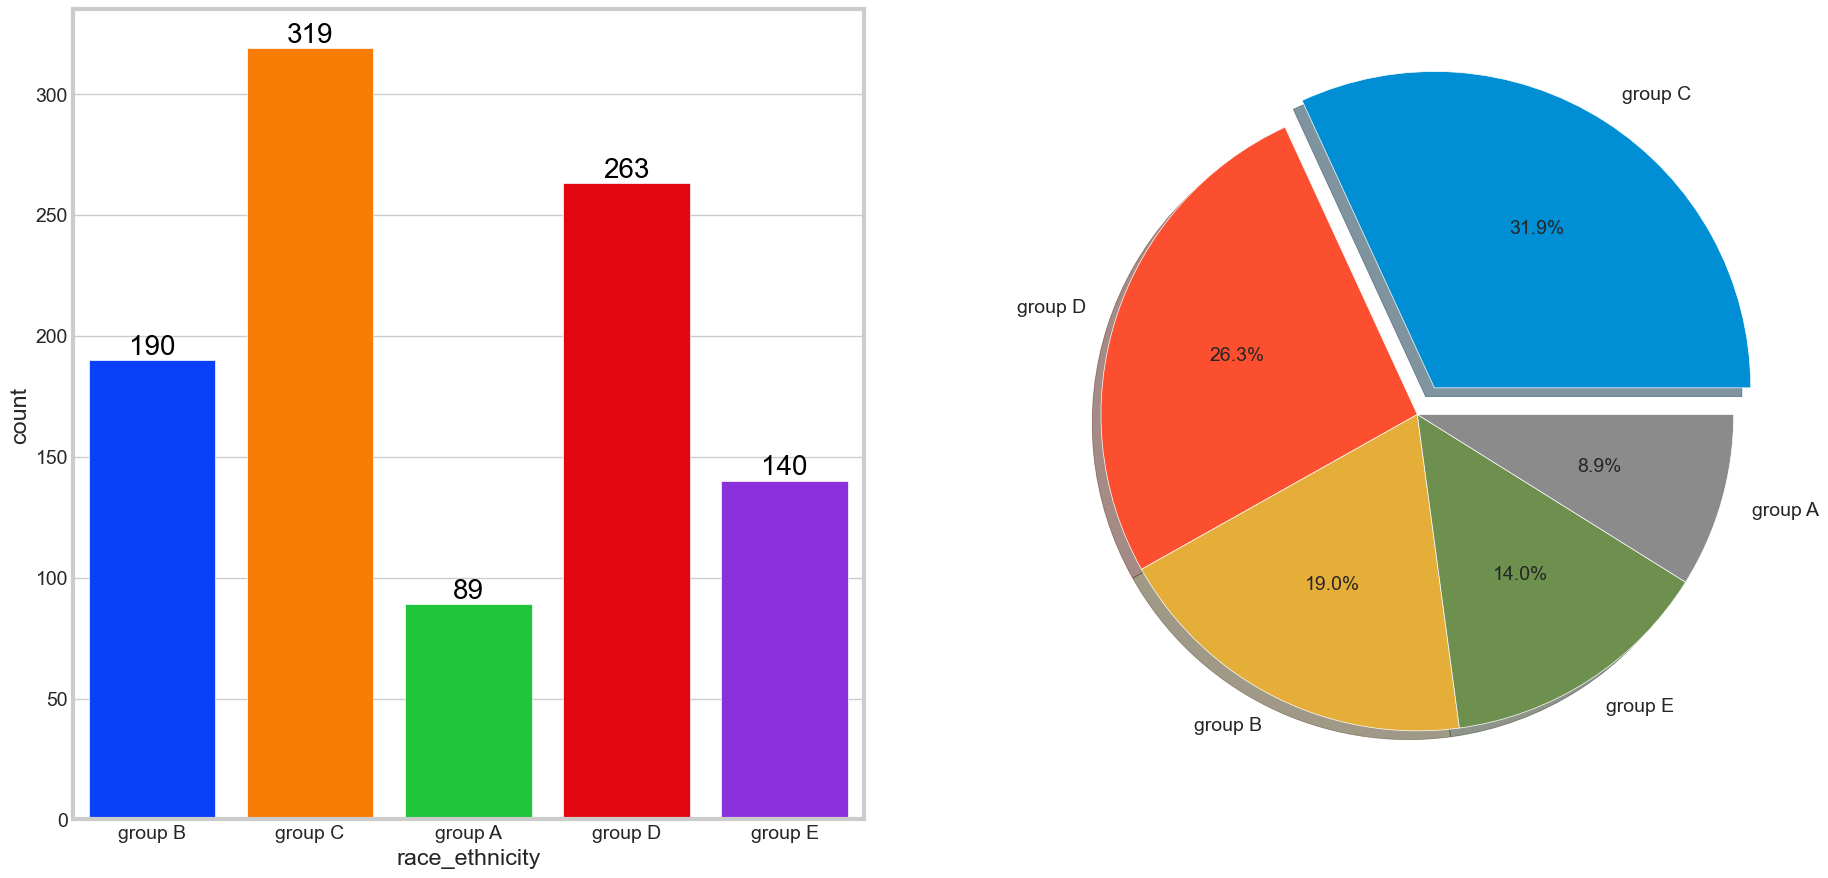

In [112]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

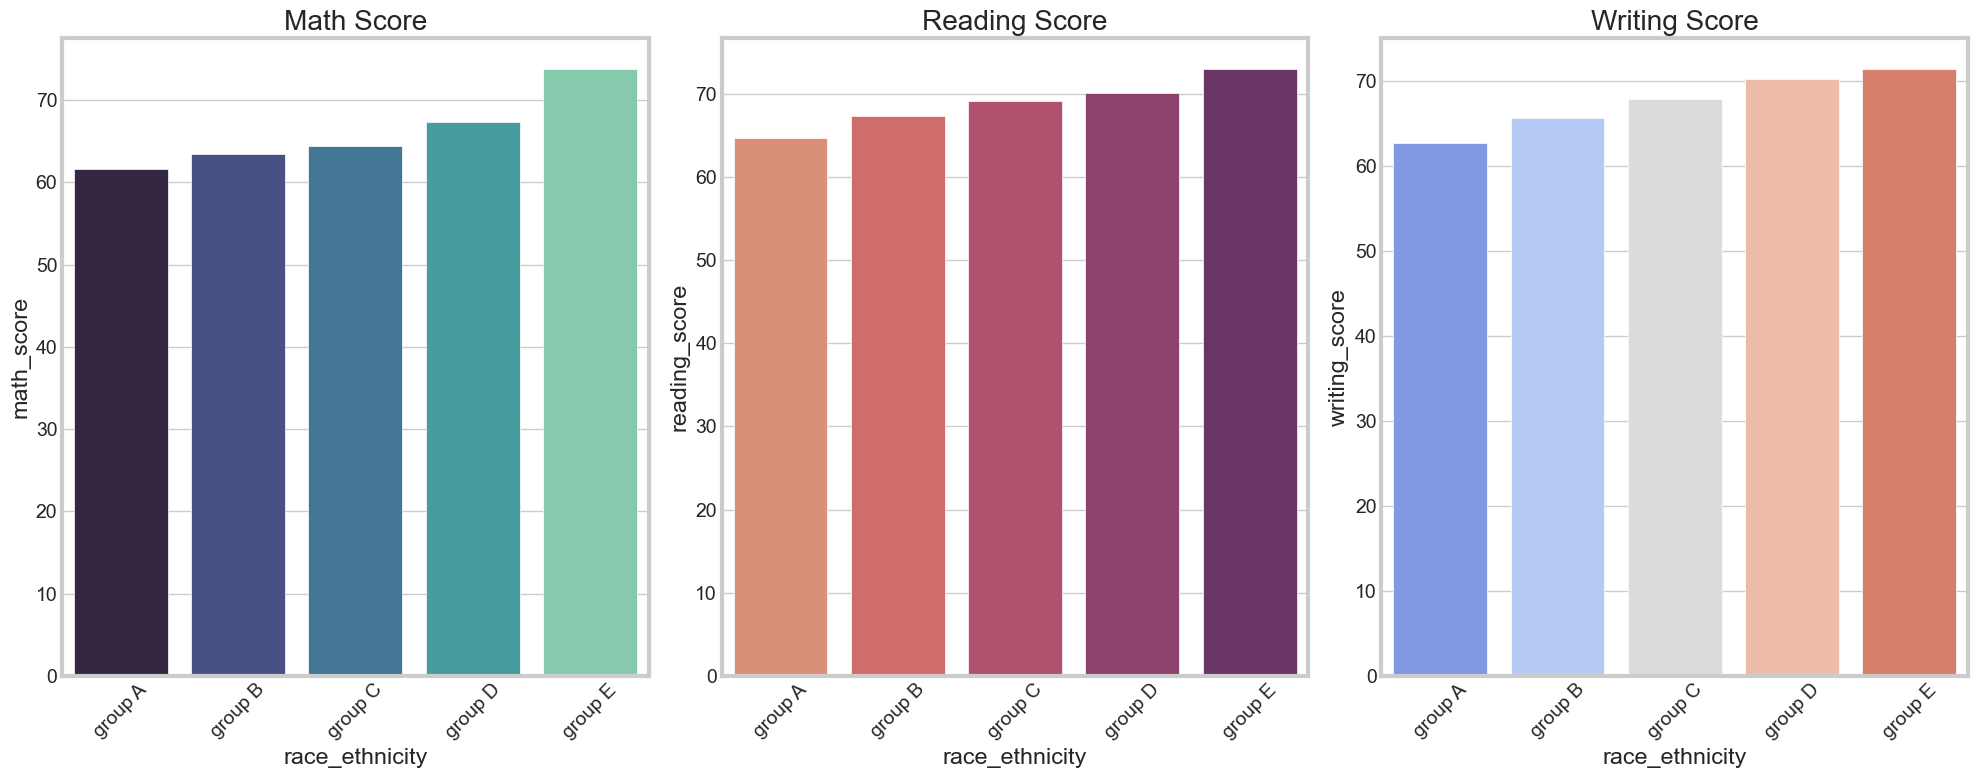

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

#group_data = df.groupby('race_ethnicity').mean()
group_data = df.groupby('race_ethnicity')[['math_score','reading_score','writing_score']].mean()
plt.figure(figsize=(20, 8))

# Math score
plt.subplot(1, 3, 1)
sns.barplot(x=group_data.index, y=group_data['math_score'], palette='mako')
plt.title('Math Score')
plt.xticks(rotation=45)

# Reading score
plt.subplot(1, 3, 2)
sns.barplot(x=group_data.index, y=group_data['reading_score'], palette='flare')
plt.title('Reading Score')
plt.xticks(rotation=45)

# Writing score
plt.subplot(1, 3, 3)
sns.barplot(x=group_data.index, y=group_data['writing_score'], palette='coolwarm')
plt.title('Writing Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

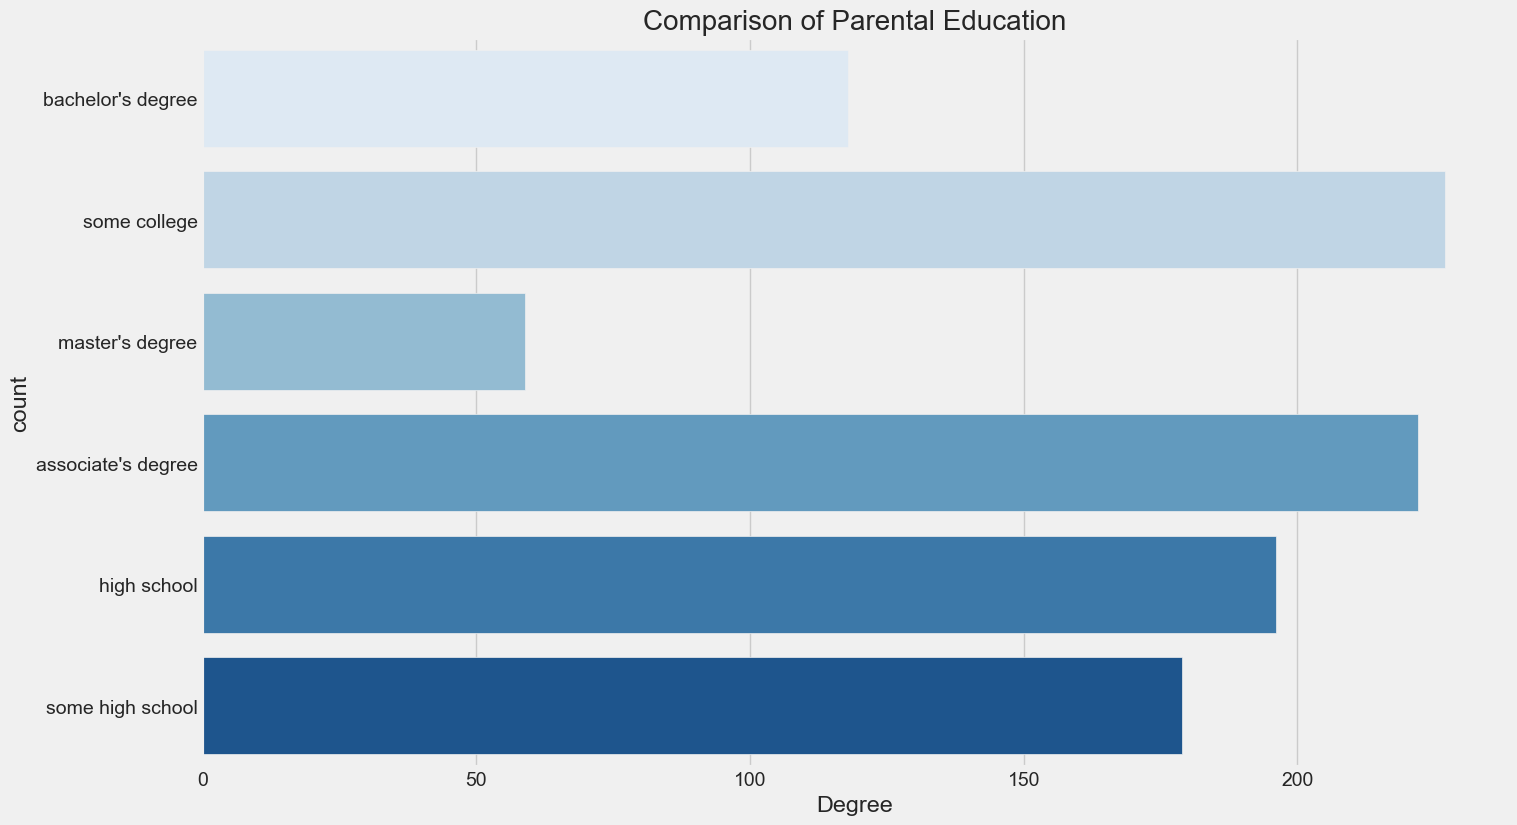

In [138]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

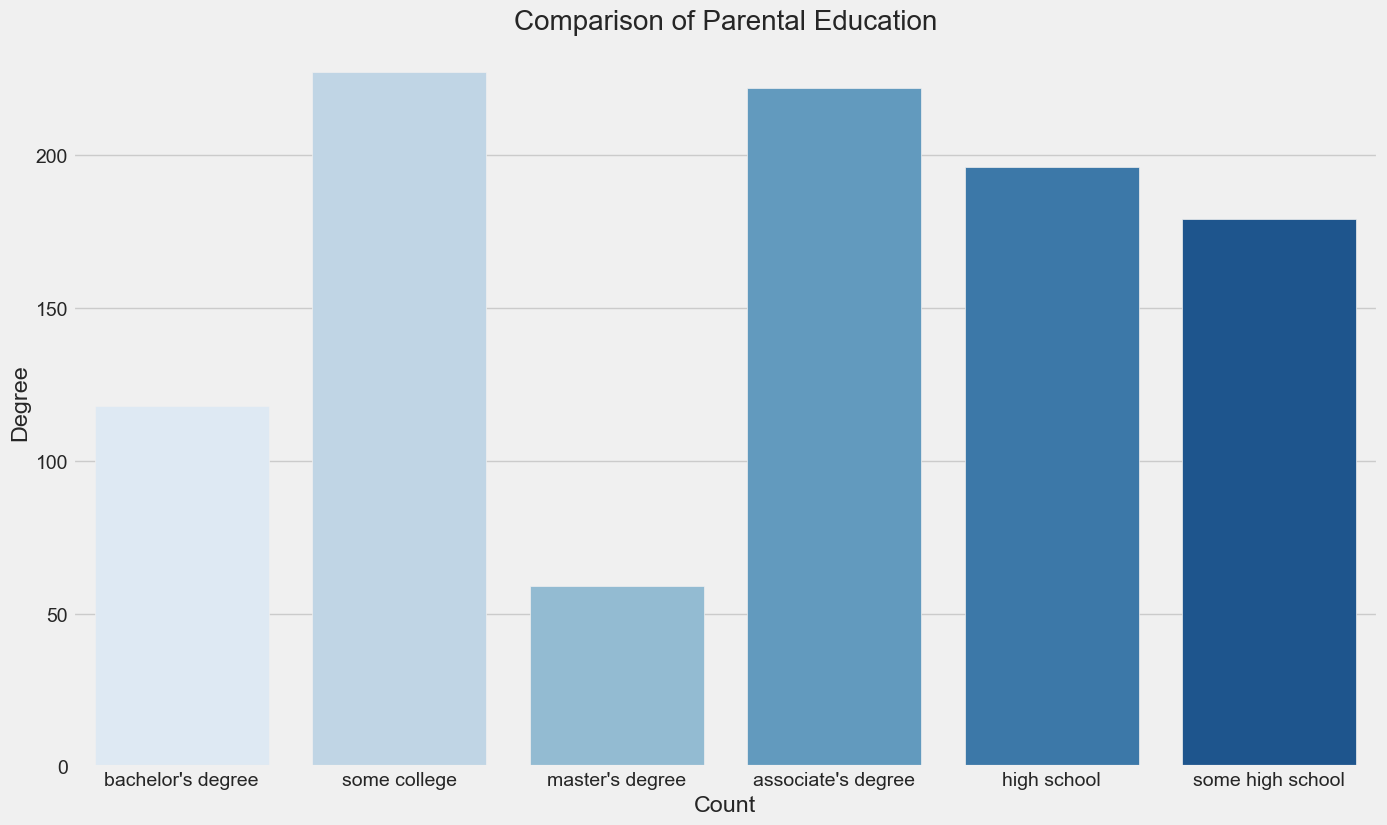

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')

sns.countplot(x='parental_level_of_education', data=df, palette='Blues')

plt.title('Comparison of Parental Education', fontsize=20)
plt.xlabel('Count')
plt.ylabel('Degree')

plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

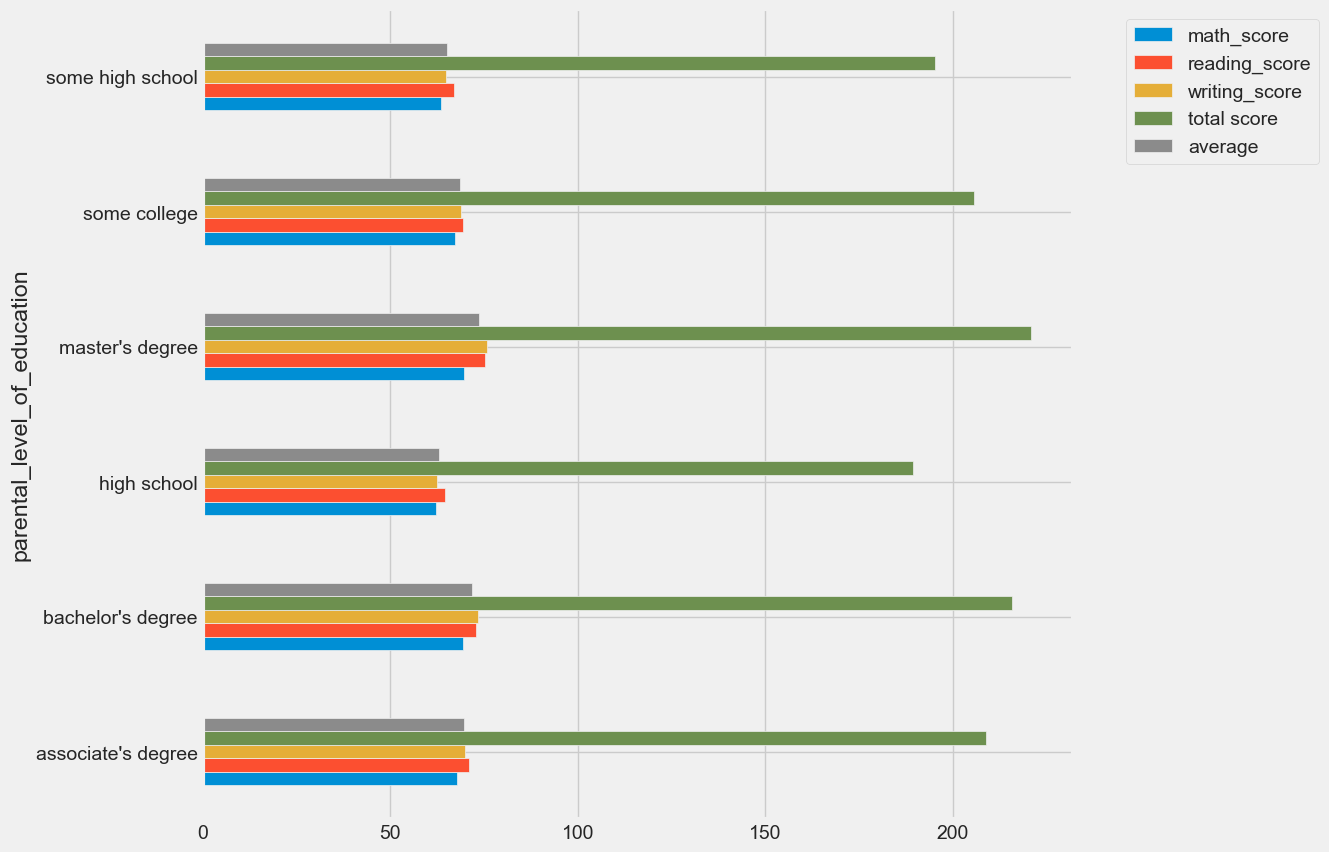

In [115]:
df.groupby('parental_level_of_education') \
  .mean(numeric_only=True) \
  .plot(kind='barh', figsize=(10,10))

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

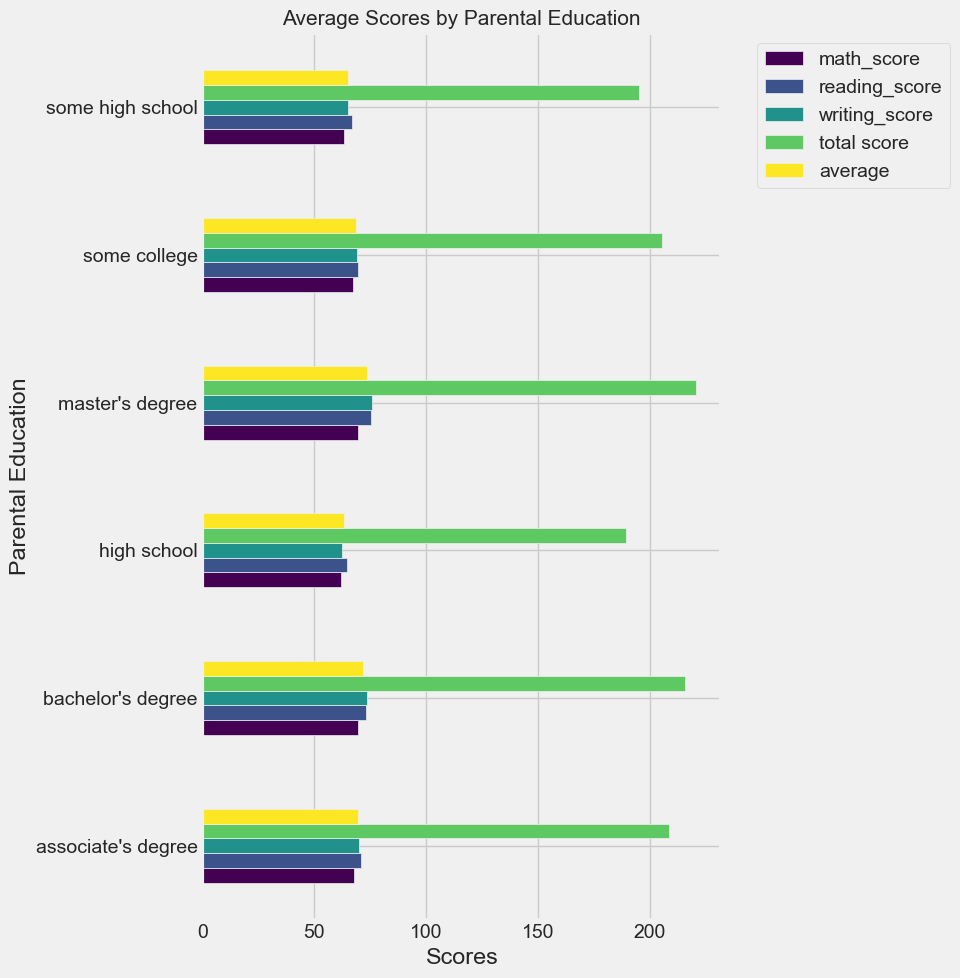

In [143]:
group_data = df.groupby('parental_level_of_education').mean(numeric_only=True)

group_data.plot(
    kind='barh',
    figsize=(10, 10),
    colormap='viridis'   # good color palette
)

plt.title('Average Scores by Parental Education', fontsize=15)
plt.xlabel('Scores')
plt.ylabel('Parental Education')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

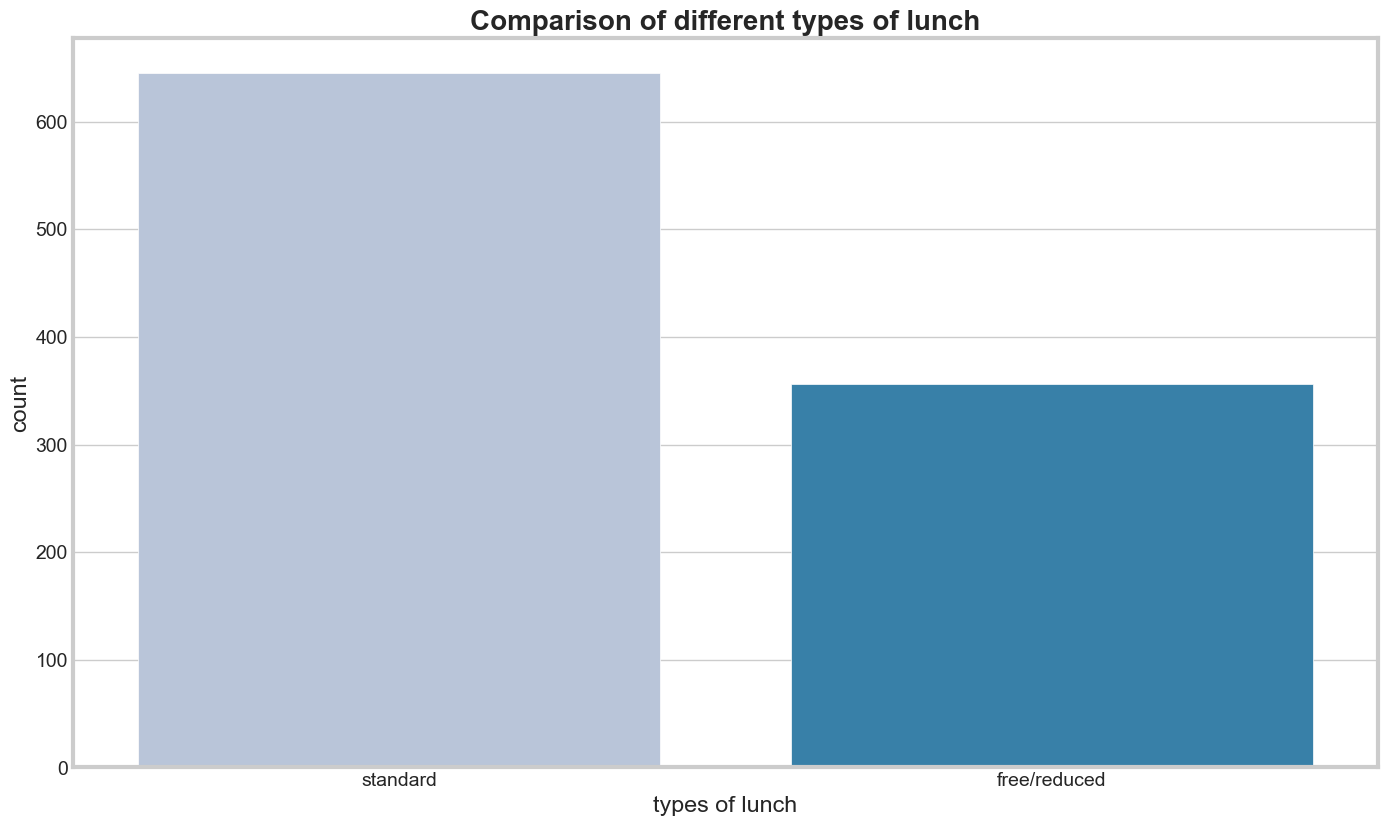

In [116]:
plt.rcParams['figure.figsize'] = (15, 9)

sns.set_style('whitegrid')   # instead of plt.style.use

sns.countplot(x=df['lunch'], palette='PuBu')

plt.title('Comparison of different types of lunch', fontweight='bold', fontsize=20)
plt.xlabel('types of lunch')
plt.ylabel('count')

plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

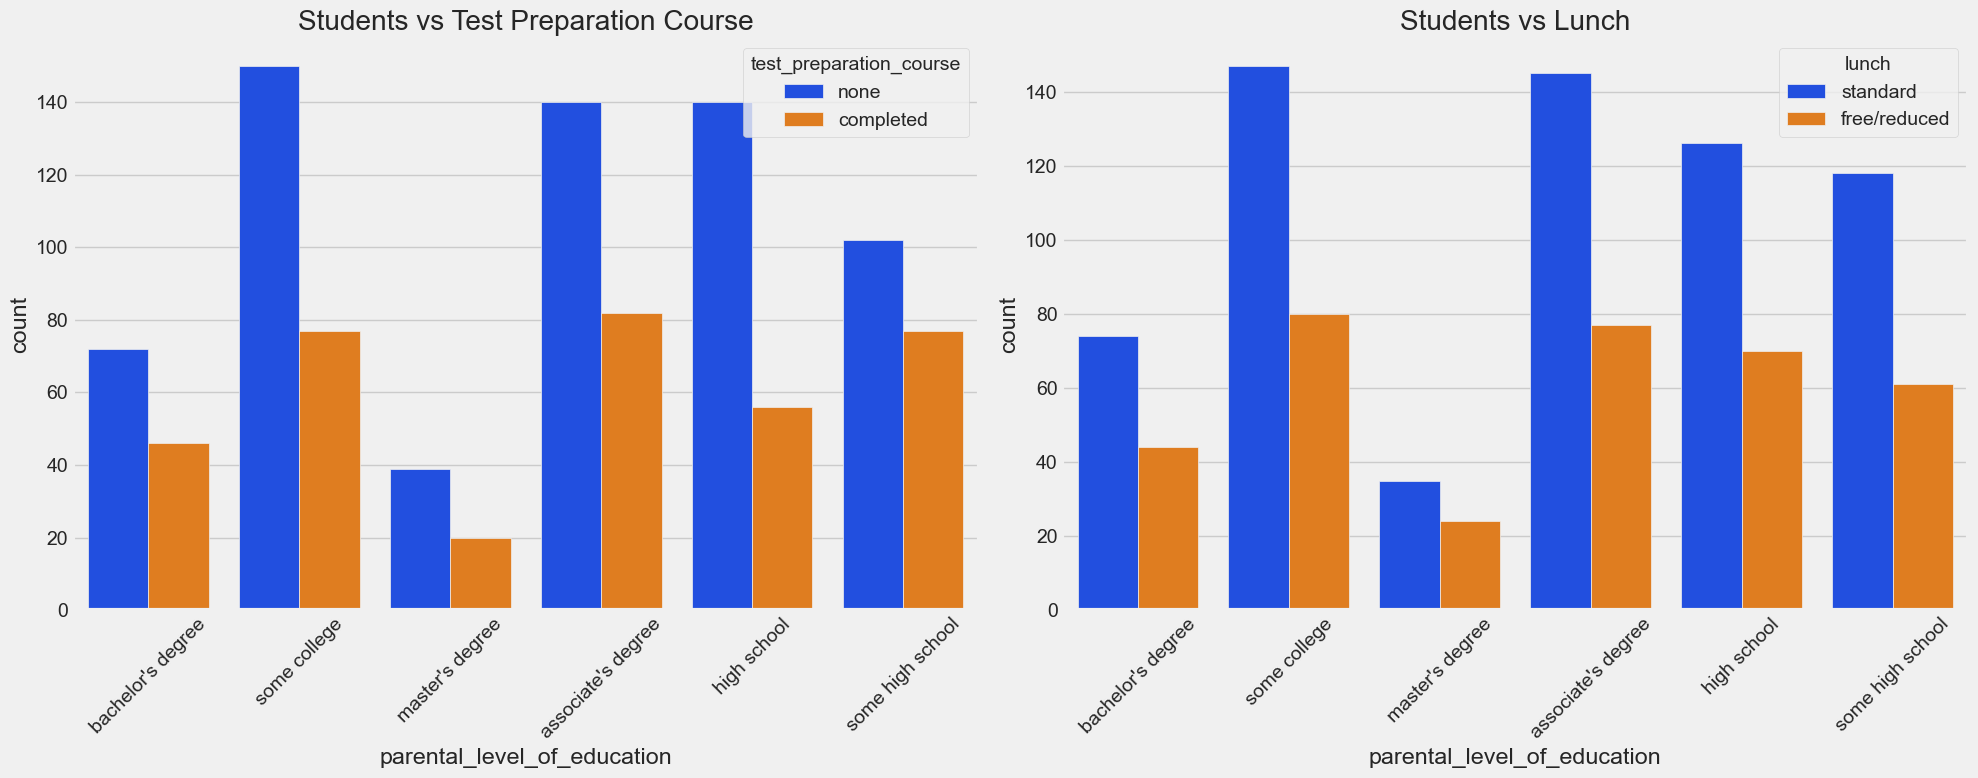

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 8))

# 1st plot
plt.subplot(1, 2, 1)
sns.countplot(
    x='parental_level_of_education',
    data=df,
    hue='test_preparation_course',
    palette='bright'
)
plt.title('Students vs Test Preparation Course')
plt.xticks(rotation=45)

# 2nd plot
plt.subplot(1, 2, 2)
sns.countplot(
    x='parental_level_of_education',
    data=df,
    hue='lunch',
    palette='bright'
)
plt.title('Students vs Lunch')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='average'>

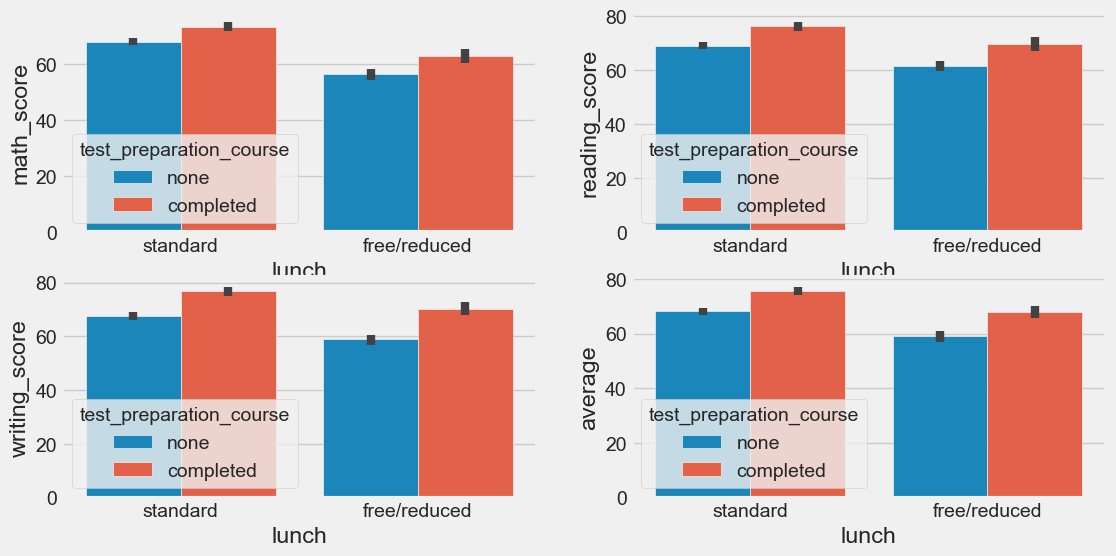

In [145]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,4)
sns.barplot(x=df['lunch'],y=df['average'],hue=df['test_preparation_course'])

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

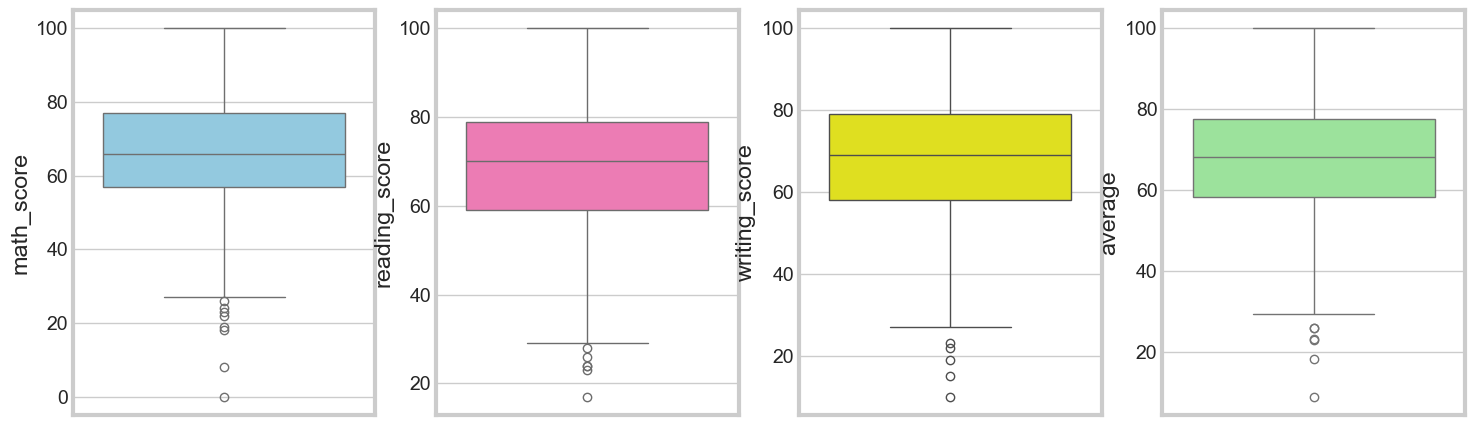

In [119]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

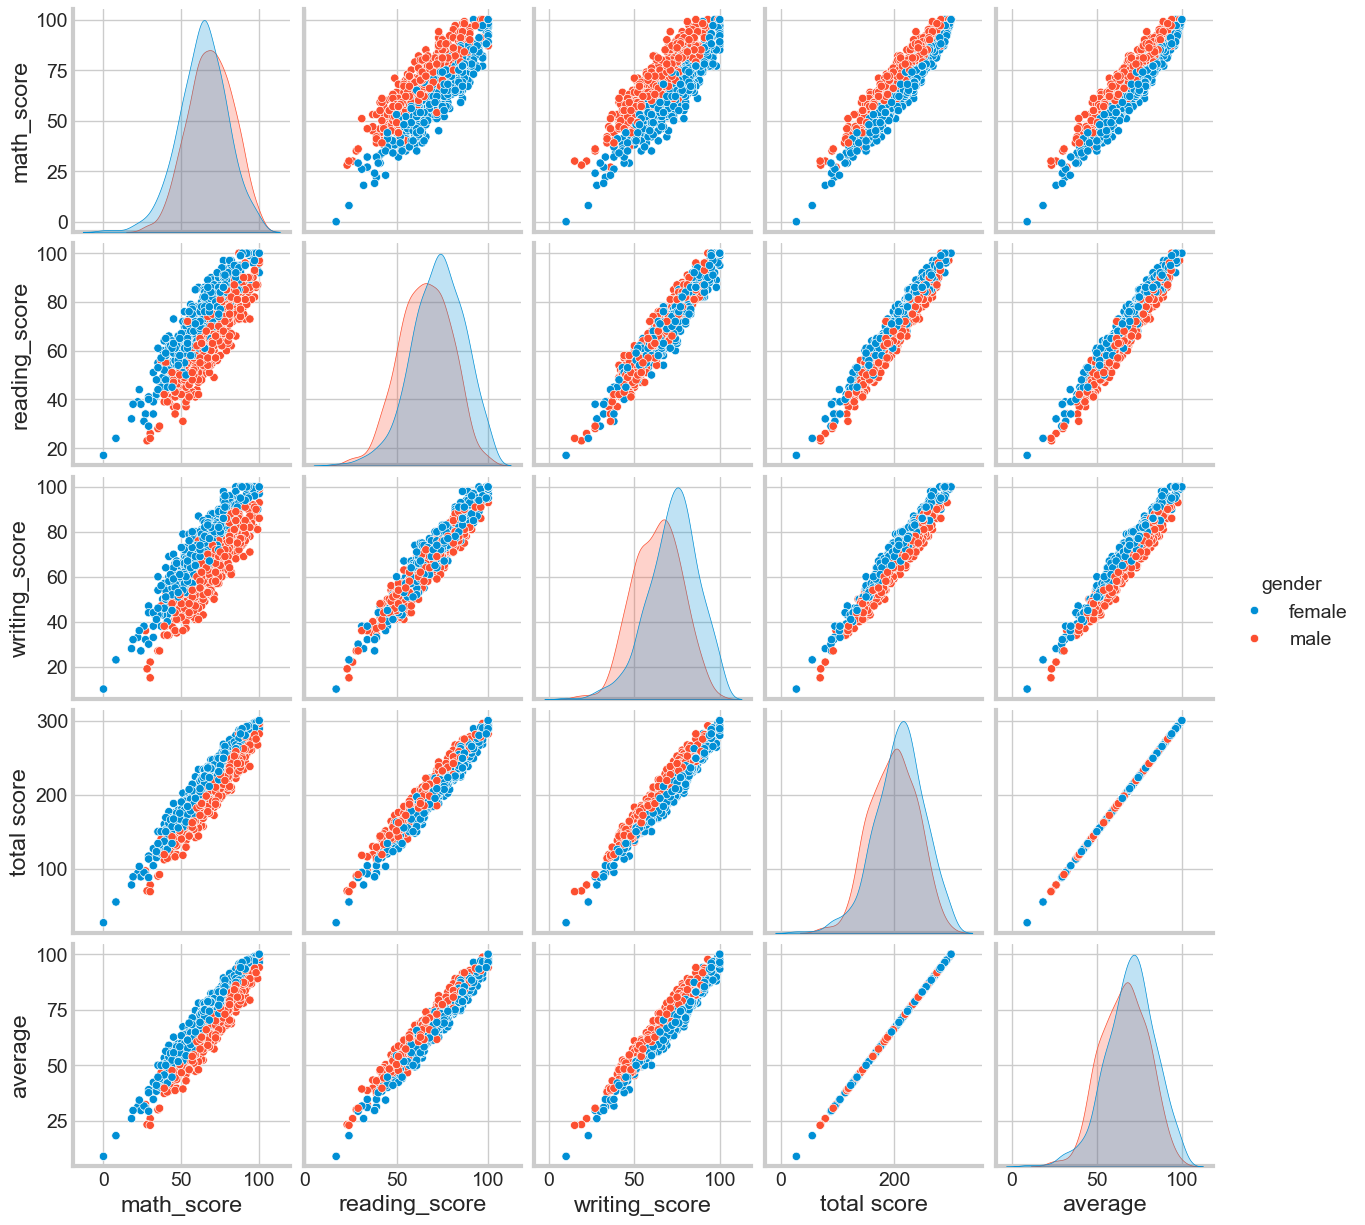

In [120]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.